# GameTheory 15c - Jeux Cooperatifs Lean (Python)

**Navigation** : [<< 15-CooperativeGames (track principal)](GameTheory-15-CooperativeGames.ipynb)) | [Index](README.md)

**Autres side tracks** : [15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb)

**Kernel** : Python 3

---

## Introduction

Ce notebook compagnon du **notebook 15b (Lean)** fournit les **illustrations Python** des concepts formalises :

- Jeu de gants (Glove Game) et calcul de Shapley
- Verification du Core vide pour les jeux de majorite
- Jeux de vote ponderes et indice de Banzhaf

Pour les implementations completes de Shapley et Core, voir le notebook 14.

### Objectifs d'apprentissage

A l'issue de ce notebook, vous saurez :

1. Calculer la **valeur de Shapley** d'un jeu cooperatif et l'illustrer sur le jeu de gants (Glove Game)
2. Verifier qu'un jeu de **majorite** peut avoir un **Core vide**
3. Calculer l'**indice de Banzhaf** sur des jeux de vote ponderes
4. Observer que les **jeux convexes** ont leur valeur de Shapley dans le Core

### Duree estimee : 25 minutes

### Prerequis
- Notebook 15 : Jeux Cooperatifs (valeur de Shapley, Core)
- Notebook 14 : implementations completes de Shapley et du Core
- Bases Python : numpy

In [1]:
# Configuration
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from math import factorial
from collections import defaultdict

print("Notebook Python compagnon pour les jeux cooperatifs (Lean)")

Notebook Python compagnon pour les jeux cooperatifs (Lean)


---

## 1. Valeur de Shapley - Rappels

La valeur de Shapley est la contribution marginale moyenne d'un joueur sur toutes les permutations :

$$\phi_i(v) = \sum_{S \subseteq N \setminus \{i\}} \frac{|S|!(n-|S|-1)!}{n!} [v(S \cup \{i\}) - v(S)]$$

In [2]:
def shapley_value_exact(v, n):
    """Calcul exact de la valeur de Shapley.
    
    Args:
        v: Fonction caracteristique v(S) ou S est un frozenset
        n: Nombre de joueurs
    
    Returns:
        Liste des valeurs de Shapley pour chaque joueur
    """
    shapley = [0.0] * n
    
    for perm in permutations(range(n)):
        coalition = set()
        for i in perm:
            marginal = v(frozenset(coalition | {i})) - v(frozenset(coalition))
            shapley[i] += marginal
            coalition.add(i)
    
    return [s / factorial(n) for s in shapley]

print("Fonction shapley_value_exact definie.")

Fonction shapley_value_exact definie.


---

## 2. Jeu de Gants (Glove Game)

**Exercice 1 du notebook 15b Lean** : Trois joueurs L1, L2 ont chacun un gant gauche, R1 a un gant droit. Une paire de gants vaut 1.

In [3]:
# Jeu de gants : L1=0, L2=1, R1=2
def glove_game(coalition):
    """Fonction caracteristique du jeu de gants.
    Joueurs 0,1 ont des gants gauches, joueur 2 a un gant droit.
    Valeur = nombre de paires completes.
    """
    left_gloves = sum(1 for i in coalition if i in {0, 1})
    right_gloves = sum(1 for i in coalition if i == 2)
    return min(left_gloves, right_gloves)

# Verification de la fonction caracteristique
print("JEU DE GANTS")
print("=" * 40)
print("Joueurs : L1=0, L2=1 (gants gauches), R1=2 (gant droit)")
print("\nFonction caracteristique :")

all_coalitions = [frozenset(c) for r in range(4) for c in combinations(range(3), r)]
for S in sorted(all_coalitions, key=lambda x: (len(x), tuple(sorted(x)))):
    labels = {0: 'L1', 1: 'L2', 2: 'R1'}
    coalition_str = '{' + ', '.join(labels[i] for i in sorted(S)) + '}' if S else '{}'
    print(f"  v({coalition_str}) = {glove_game(S)}")

JEU DE GANTS
Joueurs : L1=0, L2=1 (gants gauches), R1=2 (gant droit)

Fonction caracteristique :
  v({}) = 0
  v({L1}) = 0
  v({L2}) = 0
  v({R1}) = 0
  v({L1, L2}) = 0
  v({L1, R1}) = 1
  v({L2, R1}) = 1
  v({L1, L2, R1}) = 1


### Interpretation : Fonction caracteristique du jeu de gants

La fonction caracteristique encode la **structure de complementarite** du jeu :

| Type de coalition | Valeur | Raison |
|-------------------|--------|--------|
| Vide ou singletons | 0 | Aucune paire possible |
| {L1, L2} (deux gauches) | 0 | Pas de gant droit pour completer |
| {L1, R1} ou {L2, R1} | 1 | Une paire complete |
| {L1, L2, R1} | 1 | Une seule paire possible (1 gant droit) |

> **Point cle** : Le gant droit est la **ressource limitante**. Meme avec deux gants gauches, on ne peut former qu'une seule paire. Cette asymetrie aura un impact majeur sur les valeurs de Shapley.

In [4]:
# Calcul de Shapley pour le jeu de gants
shapley_glove = shapley_value_exact(glove_game, 3)

print("\nVALEURS DE SHAPLEY :")
labels = ['L1 (gant gauche)', 'L2 (gant gauche)', 'R1 (gant droit)']
for i, (label, val) in enumerate(zip(labels, shapley_glove)):
    print(f"  {label}: {val:.4f} = {int(val*6)}/6")

print(f"\nTotal : {sum(shapley_glove):.4f} (= v(N) = 1)")

print("\nInterpretation :")
print("  - R1 (gant droit) a une valeur de 2/3 car il possede la ressource rare")
print("  - L1 et L2 se partagent 1/3 car ils sont en competition")


VALEURS DE SHAPLEY :
  L1 (gant gauche): 0.1667 = 1/6
  L2 (gant gauche): 0.1667 = 1/6
  R1 (gant droit): 0.6667 = 4/6

Total : 1.0000 (= v(N) = 1)

Interpretation :
  - R1 (gant droit) a une valeur de 2/3 car il possede la ressource rare
  - L1 et L2 se partagent 1/3 car ils sont en competition


### Interpretation : Valeur de la rarete

Les valeurs de Shapley revelent un principe economique fondamental :

| Joueur | Ressource | Shapley | Explication |
|--------|-----------|---------|-------------|
| L1, L2 | Gant gauche (abondant) | 1/6 chacun | Competition entre detenteurs de la meme ressource |
| R1 | Gant droit (rare) | 4/6 | Monopole sur la ressource complementaire |

**Analyse des contributions marginales** :
- Quand R1 rejoint {L1} ou {L2}, il apporte 1 (creation d'une paire)
- Quand L1 rejoint {R1}, il apporte 1 (creation d'une paire)
- Quand L1 rejoint {L2, R1}, il apporte 0 (une paire existe deja)

> **Lecon economique** : La valeur d'une ressource ne depend pas seulement de son utilite intrinseque, mais de sa rarete relative par rapport aux ressources complementaires.

### Exercice : Jeu de gants etendu a 4 joueurs

**Objectif** : Etendre le jeu de gants a 4 joueurs : L1, L2 (gants gauches) et R1, R2 (gants droits). Definir la fonction caracteristique, calculer les valeurs de Shapley, et interpreter comment le marche 2-vs-2 repartit la valeur.

**Contexte** : Le jeu a 3 joueurs montre que le detenteur de la ressource rare obtient 4/6. Avec 2 gants de chaque cote, le marche est equilibre.

- **Indice :** Joueurs 0,1 = gants gauches, joueurs 2,3 = gants droits. v(S) = min(gauches, droites).
- **Etape 1 :** Definir glove_game_4(S).
- **Etape 2 :** Calculer shapley_value_exact(glove_game_4, 4).
- **Etape 3 :** Comparer avec le resultat a 3 joueurs (ressource rare vs equilibre).

In [5]:
def exercice_shapley_glove_etendu() -> dict:
    """
    Jeu de gants etendu a 4 joueurs (2 gauches, 2 droites).
    
    Returns:
        dict avec :
            'shapley_values': liste des 4 valeurs de Shapley
            'total': somme des valeurs (= v(N))
            'interpretation': texte d'interpretation
    """
    return {"shapley_values": [], "total": 0.0, "interpretation": ""}  # TODO etudiant

result_glove4 = exercice_shapley_glove_etendu()
labels_4 = ['L1', 'L2', 'R1', 'R2']
for label, val in zip(labels_4, result_glove4['shapley_values']):
    print(f"  {label}: {val:.4f}")
print(f"\nTotal: {result_glove4['total']:.4f}")
print(f"Interpretation: {result_glove4['interpretation']}")

print("Exercice a completer")


Total: 0.0000
Interpretation: 
Exercice a completer


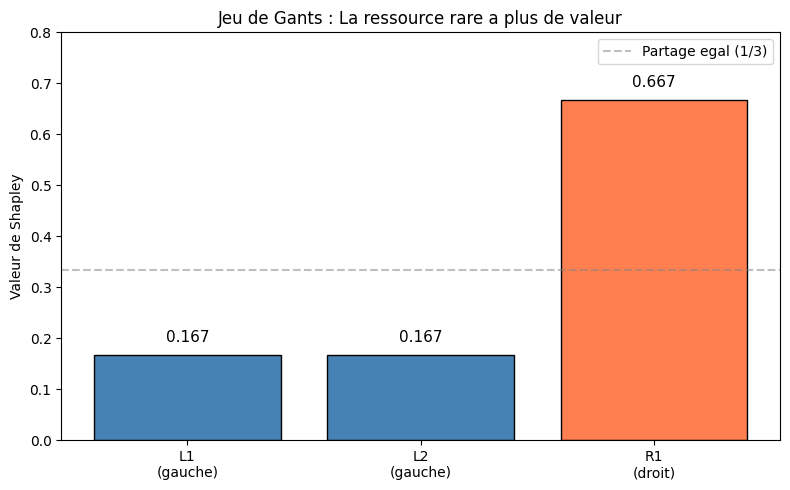

In [6]:
# Visualisation
fig, ax = plt.subplots(figsize=(8, 5))

players = ['L1\n(gauche)', 'L2\n(gauche)', 'R1\n(droit)']
colors = ['steelblue', 'steelblue', 'coral']

bars = ax.bar(players, shapley_glove, color=colors, edgecolor='black')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars, shapley_glove):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=11)

ax.set_ylabel('Valeur de Shapley')
ax.set_title('Jeu de Gants : La ressource rare a plus de valeur')
ax.set_ylim(0, 0.8)
ax.axhline(y=1/3, color='gray', linestyle='--', alpha=0.5, label='Partage egal (1/3)')
ax.legend()

plt.tight_layout()
plt.show()

---

## 3. Core Vide : Jeu de Majorite

**Exemple guide 3 du notebook 15b Lean** : Montrer que le jeu de majorite simple a 3 joueurs a un Core vide.

In [7]:
def majority_game_3(coalition):
    """Jeu de majorite simple a 3 joueurs.
    v(S) = 1 si |S| >= 2, 0 sinon.
    """
    return 1 if len(coalition) >= 2 else 0

print("JEU DE MAJORITE SIMPLE A 3 JOUEURS")
print("=" * 50)

print("\nFonction caracteristique :")
for S in sorted(all_coalitions, key=lambda x: (len(x), tuple(sorted(x)))):
    coalition_str = '{' + ', '.join(str(i+1) for i in sorted(S)) + '}' if S else '{}'
    print(f"  v({coalition_str}) = {majority_game_3(S)}")

JEU DE MAJORITE SIMPLE A 3 JOUEURS

Fonction caracteristique :
  v({}) = 0
  v({1}) = 0
  v({2}) = 0
  v({3}) = 0
  v({1, 2}) = 1
  v({1, 3}) = 1
  v({2, 3}) = 1
  v({1, 2, 3}) = 1


### Interpretation : Structure du jeu de majorite

La fonction caracteristique revele une **symetrie parfaite** entre les joueurs :

- **Coalitions perdantes** (v=0) : singletons uniquement
- **Coalitions gagnantes** (v=1) : toute paire ou plus

Cette structure est celle d'un **jeu simple symetrique** : tous les joueurs sont interchangeables, et le resultat ne depend que de la taille de la coalition.

> **Propriete importante** : Dans ce jeu, chaque joueur est **critique** (pivotal) dans exactement 2 coalitions gagnantes minimales. Par exemple, le joueur 1 est critique dans {1,2} et {1,3}.

In [8]:
print("\nPREUVE QUE LE CORE EST VIDE")
print("=" * 50)
print("""
Pour qu'une allocation (x1, x2, x3) soit dans le Core :

1. Efficacite : x1 + x2 + x3 = v({1,2,3}) = 1

2. Stabilite (aucune coalition ne peut bloquer) :
   x1 + x2 >= v({1,2}) = 1
   x1 + x3 >= v({1,3}) = 1
   x2 + x3 >= v({2,3}) = 1

En additionnant les trois contraintes de stabilite :
   2(x1 + x2 + x3) >= 3
   2 * 1 >= 3   (par efficacite x1+x2+x3=1)
   2 >= 3       CONTRADICTION!

=> Le Core est VIDE.

Intuition : chaque coalition de 2 joueurs peut "bloquer" et demander
au moins 1, mais il n'y a que 1 a partager entre les 3 joueurs.
""")


PREUVE QUE LE CORE EST VIDE

Pour qu'une allocation (x1, x2, x3) soit dans le Core :

1. Efficacite : x1 + x2 + x3 = v({1,2,3}) = 1

2. Stabilite (aucune coalition ne peut bloquer) :
   x1 + x2 >= v({1,2}) = 1
   x1 + x3 >= v({1,3}) = 1
   x2 + x3 >= v({2,3}) = 1

En additionnant les trois contraintes de stabilite :
   2(x1 + x2 + x3) >= 3
   2 * 1 >= 3   (par efficacite x1+x2+x3=1)
   2 >= 3       CONTRADICTION!

=> Le Core est VIDE.

Intuition : chaque coalition de 2 joueurs peut "bloquer" et demander
au moins 1, mais il n'y a que 1 a partager entre les 3 joueurs.



### Interpretation : Preuve du Core vide

La preuve utilise une technique classique de **sommation des contraintes** :

1. **Contraintes individuelles** : Chaque paire de joueurs exige au moins 1 (car ils forment une coalition gagnante)
2. **Sommation** : En additionnant les 3 contraintes de paires, chaque joueur apparait 2 fois
3. **Contradiction** : On obtient 2 fois le total a distribuer >= 3, soit 2 >= 3

> **Consequence pratique** : Dans un jeu de majorite simple, aucun partage ne peut satisfaire toutes les coalitions. Toute proposition sera bloquee par une coalition de 2 joueurs qui peut obtenir plus en faisant secession.

Cette situation illustre le concept d'**instabilite coalitionnelle** : meme si la grande coalition est efficace, elle ne peut pas se former de maniere stable.

In [9]:
# Shapley du jeu de majorite (tous egaux)
shapley_majority = shapley_value_exact(majority_game_3, 3)

print("\nVALEURS DE SHAPLEY :")
for i, val in enumerate(shapley_majority):
    print(f"  Joueur {i+1}: {val:.4f} = 1/3")

print("\nNote : Shapley donne une allocation 'juste' (1/3, 1/3, 1/3)")
print("mais cette allocation n'est PAS stable (pas dans le Core).")
print("\nVerification : chaque coalition de 2 peut bloquer")
print(f"  x1 + x2 = {shapley_majority[0] + shapley_majority[1]:.4f} < 1 = v({{1,2}})")


VALEURS DE SHAPLEY :
  Joueur 1: 0.3333 = 1/3
  Joueur 2: 0.3333 = 1/3
  Joueur 3: 0.3333 = 1/3

Note : Shapley donne une allocation 'juste' (1/3, 1/3, 1/3)
mais cette allocation n'est PAS stable (pas dans le Core).

Verification : chaque coalition de 2 peut bloquer
  x1 + x2 = 0.6667 < 1 = v({1,2})


---

## 4. Jeux de Vote Ponderes et Banzhaf

Un jeu de vote pondere $[q; w_1, w_2, ..., w_n]$ ou une coalition gagne si $\sum_{i \in S} w_i \geq q$.

In [10]:
def weighted_voting_game(weights, quota):
    """Cree une fonction caracteristique pour un jeu de vote pondere."""
    def v(coalition):
        return 1 if sum(weights[i] for i in coalition) >= quota else 0
    return v

def banzhaf_index(v, n):
    """Calcule l'indice de Banzhaf (normalise).
    
    Compte le nombre de coalitions ou chaque joueur est critique.
    """
    critical_counts = [0] * n
    
    # Pour chaque coalition
    for r in range(1, n + 1):
        for S in combinations(range(n), r):
            S_set = frozenset(S)
            if v(S_set) == 1:  # Coalition gagnante
                for i in S:
                    # i est critique si S\{i} perd
                    S_minus_i = frozenset(j for j in S if j != i)
                    if v(S_minus_i) == 0:
                        critical_counts[i] += 1
    
    # Normaliser
    total = sum(critical_counts)
    if total == 0:
        return [0.0] * n
    return [c / total for c in critical_counts]

# Exemple : Conseil de securite de l'ONU simplifie [39; 7,7,7,7,7, 1,1,1,1,1]
# 5 membres permanents (poids 7), 10 non-permanents (poids 1)
# Simplification : [9; 7,7,1,1,1] (2 permanents, 3 non-permanents)
weights_un = [7, 7, 1, 1, 1]
quota_un = 9
v_un = weighted_voting_game(weights_un, quota_un)

print("JEU DE VOTE PONDERE : Mini-ONU")
print("=" * 50)
print(f"[{quota_un}; {', '.join(map(str, weights_un))}]")
print("P1, P2 = permanents (poids 7), N1, N2, N3 = non-permanents (poids 1)")

shapley_un = shapley_value_exact(v_un, 5)
banzhaf_un = banzhaf_index(v_un, 5)

print("\nComparaison Shapley vs Banzhaf :")
labels = ['P1', 'P2', 'N1', 'N2', 'N3']
print(f"{'Joueur':<10} {'Poids':<10} {'Shapley':<10} {'Banzhaf':<10}")
print("-" * 40)
for label, w, s, b in zip(labels, weights_un, shapley_un, banzhaf_un):
    print(f"{label:<10} {w:<10} {s:<10.4f} {b:<10.4f}")

JEU DE VOTE PONDERE : Mini-ONU
[9; 7, 7, 1, 1, 1]
P1, P2 = permanents (poids 7), N1, N2, N3 = non-permanents (poids 1)

Comparaison Shapley vs Banzhaf :
Joueur     Poids      Shapley    Banzhaf   
----------------------------------------
P1         7          0.3000     0.2857    
P2         7          0.3000     0.2857    
N1         1          0.1333     0.1429    
N2         1          0.1333     0.1429    
N3         1          0.1333     0.1429    


### Interpretation : Indices de pouvoir

Les resultats revelent un **paradoxe classique de la theorie du vote** :

| Joueur | Poids nominal | Pouvoir reel (Shapley) | Ratio pouvoir/poids |
|--------|---------------|------------------------|---------------------|
| P1, P2 | 7 (41%) | 0.30 (30%) | 0.73 |
| N1-N3 | 1 (6%) | 0.13 (13%) | 2.17 |

**Observations cles** :

1. **Les permanents ont moins de pouvoir que leur poids suggere** : avec 41% du poids, ils n'ont que 30% du pouvoir
2. **Les non-permanents ont plus de pouvoir relatif** : leur pouvoir (13%) depasse leur poids (6%)
3. **Shapley vs Banzhaf** : les deux indices sont proches ici, mais Shapley donne legerement plus de poids aux permanents

> **Application pratique** : Dans le vrai Conseil de Securite de l'ONU, le droit de veto des permanents leur confere un pouvoir absolu (indice = 1 si veto, 0 sinon pour certaines decisions).

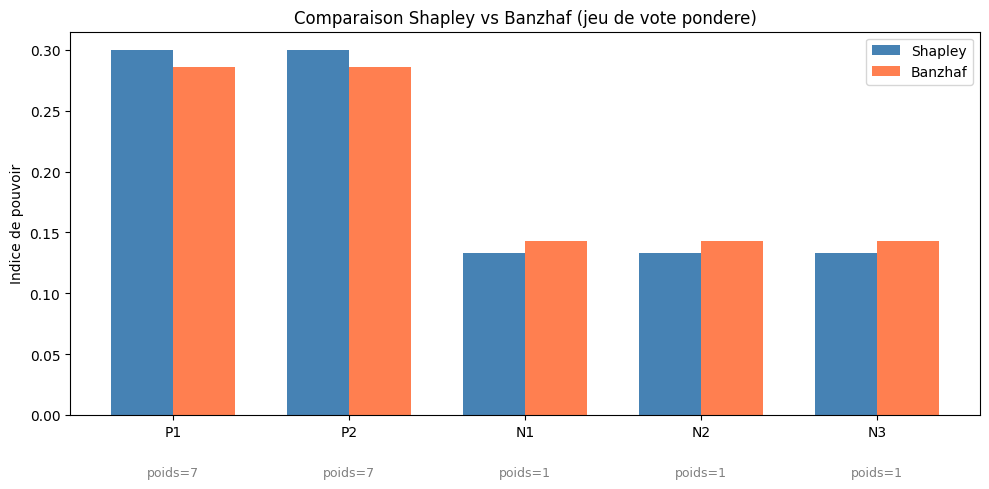

Note : Le pouvoir reel (Shapley/Banzhaf) peut differer du poids nominal!


In [11]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(labels))
width = 0.35

bars1 = ax.bar(x - width/2, shapley_un, width, label='Shapley', color='steelblue')
bars2 = ax.bar(x + width/2, banzhaf_un, width, label='Banzhaf', color='coral')

ax.set_ylabel('Indice de pouvoir')
ax.set_title('Comparaison Shapley vs Banzhaf (jeu de vote pondere)')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Ajouter les poids en annotation
for i, w in enumerate(weights_un):
    ax.annotate(f'poids={w}', xy=(i, 0), xytext=(i, -0.05),
                ha='center', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print("Note : Le pouvoir reel (Shapley/Banzhaf) peut differer du poids nominal!")

---

## 5. Jeux Convexes : Shapley dans le Core

Un jeu est **convexe** (supermodulaire) si les contributions marginales sont croissantes. Pour les jeux convexes, la valeur de Shapley est dans le Core.

In [12]:
def is_convex(v, n):
    """Verifie si un jeu est convexe.
    
    Un jeu est convexe si pour tout S, T : v(S) + v(T) <= v(S u T) + v(S n T)
    """
    for r1 in range(n + 1):
        for S in combinations(range(n), r1):
            S = frozenset(S)
            for r2 in range(n + 1):
                for T in combinations(range(n), r2):
                    T = frozenset(T)
                    lhs = v(S) + v(T)
                    rhs = v(S | T) + v(S & T)
                    if lhs > rhs + 1e-10:  # Tolerance numerique
                        return False
    return True

# Test sur le jeu de gants
print("TEST DE CONVEXITE")
print("=" * 40)
print(f"Jeu de gants convexe ? {is_convex(glove_game, 3)}")
print(f"Jeu de majorite convexe ? {is_convex(majority_game_3, 3)}")

# Jeu d'unanimite (toujours convexe)
def unanimity_game(T):
    """Jeu d'unanimite : v(S) = 1 si T inclus dans S, 0 sinon."""
    def v(coalition):
        return 1 if T <= coalition else 0
    return v

v_unan = unanimity_game(frozenset({0, 1}))
print(f"Jeu d'unanimite u_{{1,2}} convexe ? {is_convex(v_unan, 3)}")

TEST DE CONVEXITE
Jeu de gants convexe ? False
Jeu de majorite convexe ? False
Jeu d'unanimite u_{1,2} convexe ? True


### Interpretation : Tests de convexite

Les resultats revelent une propriete fondamentale des jeux cooperatifs :

| Jeu | Convexe ? | Explication |
|-----|-----------|-------------|
| **Gants** | Non | Le joueur R1 (ressource rare) a des rendements decroissants quand il rejoint de grandes coalitions |
| **Majorite** | Non | Deux joueurs quelconques suffisent pour gagner - pas de synergie supplementaire |
| **Unanimite** | Oui | Les contributions marginales sont nulles sauf pour les coalitions contenant T |

> **Intuition economique** : Un jeu est convexe lorsque "plus on est nombreux, plus chaque nouvel arrivant apporte de valeur". C'est le cas des jeux avec fortes complementarites entre joueurs.

In [13]:
# Verification que Shapley est dans le Core pour un jeu convexe
def is_in_core(allocation, v, n):
    """Verifie si une allocation est dans le Core."""
    # Efficacite
    if abs(sum(allocation) - v(frozenset(range(n)))) > 1e-10:
        return False, "Pas efficace"
    
    # Stabilite
    for r in range(1, n):
        for S in combinations(range(n), r):
            S_set = frozenset(S)
            coalition_value = sum(allocation[i] for i in S)
            if coalition_value < v(S_set) - 1e-10:
                return False, f"Coalition {S} peut bloquer"
    
    return True, "Dans le Core"

# Jeu convexe simple
def convex_game(coalition):
    """Un jeu convexe : v(S) = |S|^2 / 9."""
    return len(coalition) ** 2 / 9

print("\nJEU CONVEXE : v(S) = |S|^2 / 9")
print("=" * 40)
print(f"Convexe ? {is_convex(convex_game, 3)}")

shapley_convex = shapley_value_exact(convex_game, 3)
print(f"\nShapley : {shapley_convex}")

in_core, msg = is_in_core(shapley_convex, convex_game, 3)
print(f"Shapley dans le Core ? {in_core} - {msg}")

# Verification du jeu de majorite (non convexe, Shapley hors Core)
print(f"\nJeu de majorite :")
in_core_maj, msg_maj = is_in_core(shapley_majority, majority_game_3, 3)
print(f"Shapley dans le Core ? {in_core_maj} - {msg_maj}")


JEU CONVEXE : v(S) = |S|^2 / 9
Convexe ? True

Shapley : [0.3333333333333333, 0.3333333333333333, 0.3333333333333333]
Shapley dans le Core ? True - Dans le Core

Jeu de majorite :
Shapley dans le Core ? False - Coalition (0, 1) peut bloquer


### Exercice : Convexite et appartenance au Core

**Objectif** : Definir un jeu cooperatif a 3 joueurs avec une fonction caracteristique de votre choix. Tester la convexite avec `is_convex`, calculer la valeur de Shapley avec `shapley_value_exact`, puis verifier si Shapley appartient au Core avec `is_in_core`.

**Contexte** : Pour les jeux convexes, Shapley est garanti dans le Core. Pour les jeux non convexes, ce n'est pas certain.

- **Indice :** Essayer v(S) = |S| * (|S| - 1) / 2 (jeu convexe) et v(S) = 1 si |S| >= 2 (majorite, non convexe).
- **Etape 1 :** Definir deux fonctions caracteristiques (une convexe, une non convexe).
- **Etape 2 :** Tester la convexite de chacune.
- **Etape 3 :** Calculer Shapley et verifier l'appartenance au Core.

In [14]:
def exercice_convexite_et_core() -> dict:
    """
    Analyse convexite et Core pour deux jeux cooperatifs.
    
    Returns:
        dict avec :
            'game1': {'convex': bool, 'shapley': list, 'in_core': bool}
            'game2': {'convex': bool, 'shapley': list, 'in_core': bool}
    """
    return {
        "game1": {"convex": False, "shapley": [], "in_core": False},
        "game2": {"convex": False, "shapley": [], "in_core": False}
    }  # TODO etudiant

result_cc = exercice_convexite_et_core()
print("Jeu 1 (convexe attendu):")
print(f"  Convexe: {result_cc['game1']['convex']}")
print(f"  Shapley: {result_cc['game1']['shapley']}")
print(f"  Dans Core: {result_cc['game1']['in_core']}")

print("\nJeu 2 (non convexe attendu):")
print(f"  Convexe: {result_cc['game2']['convex']}")
print(f"  Shapley: {result_cc['game2']['shapley']}")
print(f"  Dans Core: {result_cc['game2']['in_core']}")

print("Exercice a completer")

Jeu 1 (convexe attendu):
  Convexe: False
  Shapley: []
  Dans Core: False

Jeu 2 (non convexe attendu):
  Convexe: False
  Shapley: []
  Dans Core: False
Exercice a completer


## 6. Calcul du Core et du Nucleole par programmation lineaire

Les sections precedentes ont raisonne sur le Core *au cas par cas* : la
section 3 a prouve **a la main** que le Core du jeu de majorite est vide, et
la section 5 a verifie l'appartenance de la valeur de Shapley au Core en
enumerant les coalitions. Deux questions **generales** restent ouvertes pour
un jeu *quelconque* :

1. **Le Core est-il vide ?** -- sans preuve manuelle propre a chaque jeu.
2. **Si oui, quelle allocation choisir** ? La valeur de Shapley est equitable
   mais, on va le voir, elle peut se trouver **hors du Core** ; il nous faut
   une allocation aussi *stable que possible*.

Les deux questions se ramenent a des **programmes lineaires (LP)** que l'on
resout avec un vrai solveur SOTA, `scipy.optimize.linprog` (backend **HiGHS**).

### Le least-core et le test computationnel de vacuite

On *relache* les contraintes de stabilite du Core par une marge `epsilon`
et on **maximise** cette marge :

$$\max_{x,\,\epsilon}\ \epsilon \quad \text{s.c.} \quad \sum_{i\in S} x_i \ge v(S) + \epsilon \ \ \forall S \subsetneq N,\ S\neq\varnothing,\qquad \sum_{i\in N} x_i = v(N).$$

Le signe de la marge optimale `epsilon*` **decide** la vacuite du Core :

- `epsilon* > 0` : le Core a un interieur (toutes les coalitions sont satisfaites avec du jeu) ;
- `epsilon* = 0` : le Core est non vide mais reduit a sa frontiere ;
- `epsilon* < 0` : le Core est **vide** ; l'ensemble des solutions optimales est le **least-core**, la meilleure approximation stable.

In [15]:
from scipy.optimize import linprog

def proper_coalitions(n):
    # Toutes les coalitions S non vides et strictement incluses dans N.
    from itertools import combinations
    return [frozenset(S) for r in range(1, n) for S in combinations(range(n), r)]

def least_core_epsilon(v, n):
    # LP : max epsilon s.c. x(S) >= v(S) + epsilon (S propre) et x(N) = v(N).
    # Renvoie (epsilon*, x*, resultat_scipy). epsilon* >= 0 <=> Core non vide.
    coals = proper_coalitions(n)
    c = [0.0] * n + [-1.0]                 # on minimise -epsilon
    A_ub, b_ub = [], []
    for S in coals:
        row = [0.0] * (n + 1)
        for i in S:
            row[i] = -1.0                  # -x(S)
        row[n] = 1.0                       # + epsilon
        A_ub.append(row); b_ub.append(-v(S))   # -x(S) + epsilon <= -v(S)
    A_eq = [[1.0] * n + [0.0]]
    b_eq = [v(frozenset(range(n)))]
    res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                  bounds=[(None, None)] * (n + 1), method="highs")
    return res.x[n], res.x[:n], res

jeux = [("Jeu de gants", glove_game), ("Jeu de majorite", majority_game_3),
        ("Jeu convexe |S|^2/9", convex_game)]

print("DIAGNOSTIC DU CORE PAR LEAST-CORE (LP HiGHS)")
print("=" * 56)
for nom, v in jeux:
    eps, x, res = least_core_epsilon(v, 3)
    verdict = "Core NON VIDE" if eps > -1e-9 else "Core VIDE"
    print(f"\n{nom} (statut LP : {res.message.split('.')[0].lower()})")
    print(f"  epsilon* = {eps:+.4f}  ->  {verdict}")
    print(f"  point least-core x* = {[round(float(xi), 4) for xi in x]}")


DIAGNOSTIC DU CORE PAR LEAST-CORE (LP HiGHS)

Jeu de gants (statut LP : optimization terminated successfully)
  epsilon* = -0.0000  ->  Core NON VIDE
  point least-core x* = [-0.0, -0.0, 1.0]

Jeu de majorite (statut LP : optimization terminated successfully)
  epsilon* = -0.3333  ->  Core VIDE
  point least-core x* = [0.3333, 0.3333, 0.3333]

Jeu convexe |S|^2/9 (statut LP : optimization terminated successfully)
  epsilon* = +0.2222  ->  Core NON VIDE
  point least-core x* = [0.3333, 0.3333, 0.3333]


### Interpretation : le signe de epsilon* diagnostique le Core

Le solveur retrouve **par le calcul** ce que les sections precedentes avaient
etabli a la main, et le generalise :

- **Jeu de gants** : `epsilon* = 0` -- le Core est non vide mais reduit a son
  unique point `(0, 0, 1)` (le detenteur du gant droit rafle tout). Marge nulle :
  on est sur la frontiere.
- **Jeu de majorite** : `epsilon* = -1/3 < 0` -- le Core est **vide**, exactement
  la conclusion de la preuve manuelle de la section 3, ici obtenue *automatiquement*
  pour n'importe quel jeu. La marge `-1/3` quantifie l'instabilite : chaque paire
  recoit 2/3 alors qu'elle peut exiger 1.
- **Jeu convexe** : `epsilon* = +0.22 > 0` -- le Core a un interieur, conforme au
  theoreme (les jeux convexes ont un Core non vide), section 5.

C'est le **test computationnel de vacuite du Core**, valable pour tout jeu, la
ou la preuve manuelle devait etre refaite a chaque fois.

### Le nucleole : l'allocation canoniquement stable

Le least-core peut encore contenir plusieurs allocations. Le **nucleole**
(Schmeidler, 1969) selectionne *la* plus equitable d'entre elles : il
**minimise lexicographiquement le vecteur des exces** trie par ordre
decroissant, ou l'exces d'une coalition `S` pour une allocation `x` est
`e(S, x) = v(S) - x(S)` (le "mecontentement" de `S`). On rend d'abord le plus
grand mecontentement aussi petit que possible, puis le deuxieme, etc.

Proprietes (Schmeidler) : le nucleole **existe toujours**, il est **unique**,
et il **appartient au Core des que celui-ci est non vide**. Il se calcule par
une **suite finie de programmes lineaires** (algorithme de Maschler) : on
resout le LP du least-core, on *fige* les coalitions devenues serrees comme
egalites, puis on recommence sur les coalitions restantes jusqu'a determiner
entierement l'allocation.

In [16]:
def nucleolus(v, n):
    # Nucleole par LPs sequentiels (Maschler) : maximise puis fige les exces,
    # par marges decroissantes. Renvoie (x*, nombre_de_LP).
    coals = proper_coalitions(n)
    vN = v(frozenset(range(n)))
    fixed = []                 # (coalition, epsilon fige) -> contraintes d'egalite
    remaining = list(coals)
    x_star, rounds = None, 0
    while remaining:
        rounds += 1
        c = [0.0] * n + [-1.0]
        A_ub, b_ub = [], []
        for S in remaining:
            row = [0.0] * (n + 1)
            for i in S:
                row[i] = -1.0
            row[n] = 1.0
            A_ub.append(row); b_ub.append(-v(S))
        A_eq = [[1.0] * n + [0.0]]; b_eq = [vN]
        for (S, eps_fix) in fixed:
            row = [0.0] * (n + 1)
            for i in S:
                row[i] = 1.0
            A_eq.append(row); b_eq.append(v(S) + eps_fix)
        res = linprog(c, A_ub=A_ub, b_ub=b_ub, A_eq=A_eq, b_eq=b_eq,
                      bounds=[(None, None)] * (n + 1), method="highs")
        if not res.success:
            break
        eps = res.x[n]; x_star = res.x[:n]
        newly = [S for S in remaining
                 if abs(sum(x_star[i] for i in S) - v(S) - eps) < 1e-6]
        if not newly:
            break
        fixed += [(S, eps) for S in newly]
        remaining = [S for S in remaining if S not in newly]
    return x_star, rounds

print("NUCLEOLE vs VALEUR DE SHAPLEY")
print("=" * 56)
for nom, v in jeux:
    nuc, nlp = nucleolus(v, 3)
    sh = shapley_value_exact(v, 3)
    in_core_nuc, _ = is_in_core(nuc, v, 3)
    in_core_sh, _ = is_in_core(sh, v, 3)
    print(f"\n{nom} ({nlp} LP resolus)")
    print(f"  Nucleole = {[round(float(z), 4) for z in nuc]}  -> dans le Core : {in_core_nuc}")
    print(f"  Shapley  = {[round(float(z), 4) for z in sh]}  -> dans le Core : {in_core_sh}")


NUCLEOLE vs VALEUR DE SHAPLEY

Jeu de gants (2 LP resolus)
  Nucleole = [-0.0, -0.0, 1.0]  -> dans le Core : True
  Shapley  = [0.1667, 0.1667, 0.6667]  -> dans le Core : False

Jeu de majorite (2 LP resolus)
  Nucleole = [0.3333, 0.3333, 0.3333]  -> dans le Core : False
  Shapley  = [0.3333, 0.3333, 0.3333]  -> dans le Core : False

Jeu convexe |S|^2/9 (1 LP resolus)
  Nucleole = [0.3333, 0.3333, 0.3333]  -> dans le Core : True
  Shapley  = [0.3333, 0.3333, 0.3333]  -> dans le Core : True


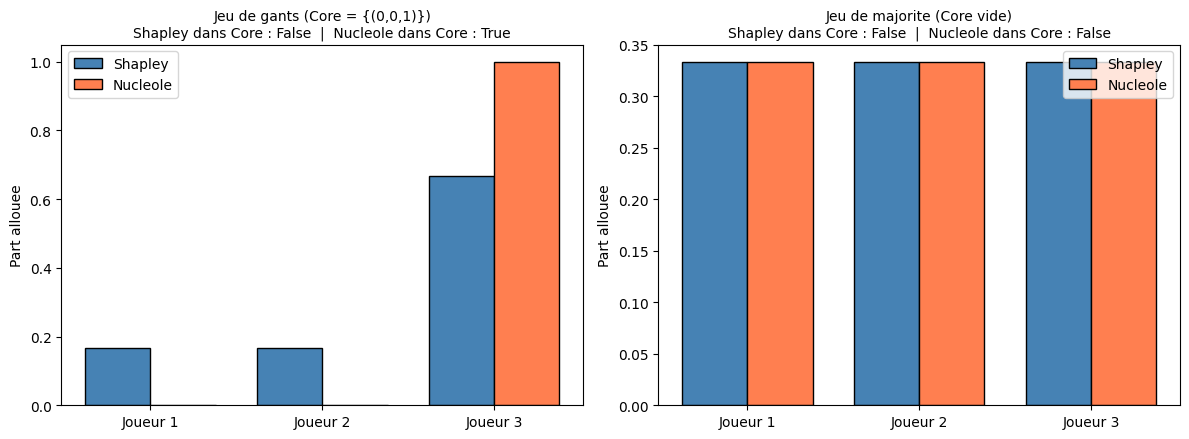

Lecture : a gauche, Shapley sort du Core (le gant droit devrait tout rafler),
le nucleole y reste. A droite (Core vide), les deux coincident par symetrie.


In [17]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (nom, v) in zip(axes, [("Jeu de gants (Core = {(0,0,1)})", glove_game),
                               ("Jeu de majorite (Core vide)", majority_game_3)]):
    nuc, _ = nucleolus(v, 3)
    sh = shapley_value_exact(v, 3)
    idx = np.arange(3); w = 0.38
    ax.bar(idx - w/2, sh, w, label="Shapley", color="steelblue", edgecolor="black")
    ax.bar(idx + w/2, nuc, w, label="Nucleole", color="coral", edgecolor="black")
    in_sh, _ = is_in_core(sh, v, 3); in_nuc, _ = is_in_core(nuc, v, 3)
    ax.set_title(f"{nom}\nShapley dans Core : {in_sh}  |  Nucleole dans Core : {in_nuc}",
                 fontsize=10)
    ax.set_xticks(idx); ax.set_xticklabels(["Joueur 1", "Joueur 2", "Joueur 3"])
    ax.set_ylabel("Part allouee"); ax.legend(); ax.axhline(0, color="gray", lw=0.6)
plt.tight_layout(); plt.show()
print("Lecture : a gauche, Shapley sort du Core (le gant droit devrait tout rafler),")
print("le nucleole y reste. A droite (Core vide), les deux coincident par symetrie.")


### Interpretation : quand utiliser Shapley, le nucleole ou le least-core ?

| Concept | Ce qu'il optimise | Toujours defini ? | Dans le Core ? | Cout de calcul |
|---------|-------------------|-------------------|----------------|----------------|
| **Valeur de Shapley** | contribution marginale moyenne (equite) | oui | **non** (cf. jeu de gants) | enumeration des permutations |
| **Nucleole** | minimise lexicographiquement le mecontentement maximal (stabilite) | **oui** | **oui** des que le Core est non vide | suite finie de LP |
| **Least-core (`epsilon*`)** | marge de stabilite maximale | oui | diagnostique vide / non vide | un seul LP |

Le jeu de gants est le cas discriminant : la valeur de Shapley `(1/6, 1/6, 2/3)`
recompense les deux gants gauches alors qu'ils sont en surnombre, et **sort du
Core** ; le nucleole `(0, 0, 1)` donne tout au gant droit -- la seule allocation
stable. Sur le jeu de majorite (Core vide) le nucleole reste defini et coincide
avec Shapley par symetrie. Le nucleole est donc le concept de solution canonique
quand on exige la **stabilite** plutot que l'**equite marginale** -- au prix d'une
sequence de programmes lineaires plutot que d'une simple moyenne.

---

## Resume

| Concept | Implementation Python |
|---------|----------------------|
| Shapley exact | `shapley_value_exact(v, n)` |
| Banzhaf | `banzhaf_index(v, n)` |
| Vote pondere | `weighted_voting_game(weights, quota)` |
| Test convexite | `is_convex(v, n)` |
| Test Core | `is_in_core(allocation, v, n)` |

**Lien avec le notebook 15b Lean** :

| Notebook 15b (Lean) | Notebook 15c (Python) |
|---------------------|----------------------|
| Axiomes de Shapley | Calcul numerique |
| Theoreme d'unicite | Verification empirique |
| Definition du Core | Test d'appartenance |
| Jeux de vote | Banzhaf et comparaison |

---

**Navigation** : [← GameTheory-15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb) | [Index](GameTheory-1-Setup.ipynb) | [Fin de la serie]

---

## 13. Exercices

### Exercice 1 : Jeu de l'aeroport

Trois compagnies aeriennes partagent un aeroport. Les couts de construction selon les coalitions (en M€) sont :
- v({A})=10, v({B})=20, v({C})=30
- v({A,B})=25, v({A,C})=35, v({B,C})=40, v({A,B,C})=50

Calculez la valeur de Shapley pour chaque compagnie.

### Exercice 2 : Jeu de majorite politique

Quatre partis (A=40%, B=30%, C=20%, D=10%) doivent former une coalition majoritaire (>50%). Calculez les indices de Banzhaf pour determiner le pouvoir de vote reel.

### Exercice 3 : Jeu de fusion d'entreprises

Trois entreprises ont des valeurs solo (v({1})=100, v({2})=150, v({3})=200). En fusion elles valent v({1,2})=350, v({1,3})=400, v({2,3})=450, v({1,2,3})=700. Le Core est-il non-vide ? Calculez Shapley et verifiez s'il appartient au Core.

In [18]:
# Espace pour les exercices

# Exemple guide 1 : Jeu de l'aeroport
def airport_value(coalition):
    # TODO etudiant : definir la fonction caracteristique
    return None  # TODO etudiant : remplacer par les valeurs

# TODO etudiant : calculer shapley_value_exact(airport_value, 3)

# Exemple guide 2 : Partis politiques
def political_game(coalition):
    # TODO etudiant : renvoyer 1 si la coalition est majoritaire (>50%), 0 sinon
    weights = {0: 40, 1: 30, 2: 20, 3: 10}  # poids en %
    return None  # TODO etudiant

# TODO etudiant : calculer banzhaf_index(political_game, 4)

# Exemple guide 3 : Fusion d'entreprises
def merger_value(coalition):
    # TODO etudiant : definir les valeurs de coalition
    return None  # TODO etudiant

# TODO etudiant : is_convex(merger_value, 3), core, shapley

print("Exercice a completer")

Exercice a completer


## Resume et perspectives

Ce notebook compagnon a illustre les concepts fondamentaux de la theorie des jeux cooperatifs a travers des implementations Python concretes. La valeur de Shapley, calculee exactement par enumeration des permutations, a revele le principe de rarete dans le jeu de gants ou le detenteur de la ressource complementaire rare obtient 4/6 de la valeur totale. La preuve du Core vide pour le jeu de majorite simple a 3 joueurs a montre comment la sommation des contraintes de stabilite mene a une contradiction (2 >= 3), illustrant l'instabilite coalitionnelle inhierente a ce type de jeu. Les indices de pouvoir de Shapley et Banzhaf ont ensuite demontre que le pouvoir reel peut differer significativement du poids nominal dans les jeux de vote ponderes, les non-permanents du Conseil de securite disposant d'un ratio pouvoir/poids plus eleve que les permanents.

La propriete de convexite s'est revelee determinante pour la stabilite des allocations : dans les jeux convexes (supermodulaires), la valeur de Shapley est garantie d'appartenir au Core, tandis que les jeux non convexes comme celui de la majorite ou des gants ne beneficient pas de cette garantie. Cette distinction entre "juste" (Shapley) et "stable" (Core) est au coeur de la theorie cooperative, et les exercices proposes permettent d'approfondir ces concepts sur des applications concretes (aeroport, fusion d'entreprises, jeux politiques).

Les concepts de valeur de Shapley, de Core et d'indices de pouvoir trouvent des applications directes en economie (repartition des couts), en sciences politiques (analyse du pouvoir de vote) et en intelligence artificielle (explicabilite des modeles via les valeurs de Shapley en ML). Le passage a l'echelle vers des jeux a un grand nombre de joueurs necessite des methodes d'approximation Monte Carlo de la valeur de Shapley, constituant un domaine de recherche actif.

> **Lien avec la formalisation Lean** : Les concepts de ce notebook — jeux cooperatifs TU, valeur de Shapley, Core, convexite — sont construits formellement dans le notebook compagnon [GT-15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb) et la librairie [`cooperative_games_lean/`](cooperative_games_lean/). Le module `Basic.lean` (473 lignes, 1 sorry) definit `TUGame`, les coalitions, le Core et la convexite, et prouve le theoreme de Bondareva-Shapley (condition necessaire et suffisante pour le Core non-vide). Le module `Shapley.lean` (1042 lignes, 0 sorry) formalise les 4 axiomes de Shapley (efficacite, symetrie, joueur nul, additivite) et prouve l'unicite de la valeur. Le jeu de gants (Glove Game) et le jeu de majorite illustres numeriquement ci-dessus y sont egalement traites.

---

**Notebook precedent**: [GameTheory-15b-Lean-CooperativeGames](GameTheory-15b-Lean-CooperativeGames.ipynb)  
**Notebook suivant**: [GameTheory-16-MechanismDesign](GameTheory-16-MechanismDesign.ipynb)